In [1]:
!git clone https://github.com/SahputraS/MIGHTE-respicast-jointGBM.git
%cd MIGHTE-respicast-jointGBM

Cloning into 'MIGHTE-respicast-jointGBM'...
remote: Enumerating objects: 274, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (247/247), done.
remote: Total 274 (delta 134), reused 108 (delta 21), pack-reused 0 (from 0)
Receiving objects: 100% (274/274), 7.19 MiB | 3.89 MiB/s, done.
Resolving deltas: 100% (134/134), done.
/content/MIGHTE-respicast-jointGBM


In [2]:
%cd /content/MIGHTE-respicast-jointGBM
!git pull origin main

/content/MIGHTE-respicast-jointGBM
From https://github.com/SahputraS/MIGHTE-respicast-jointGBM
 * branch            main       -> FETCH_HEAD
Already up to date.


In [3]:
!pip install \
  "lightgbm>=4.3" \
  "lightgbmlss>=0.2.5"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 899.7/899.7 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 861.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 56.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 29.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 756.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28

In [ ]:
!pip install optuna

In [ ]:
# Verify the correct version
import lightgbm as lgb
import lightgbmlss
print("lightgbm:", lgb.__version__)
import importlib.metadata
print("lightgbmlss:", importlib.metadata.version("lightgbmlss"))

lightgbm: 4.6.0
lightgbmlss: 0.6.1


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import optuna

## Clone the respicast data

In [ ]:
!git clone --depth 1 https://github.com/european-modelling-hubs/RespiCast-SyndromicIndicators.git

fatal: destination path 'RespiCast-SyndromicIndicators' already exists and is not an empty directory.


In [ ]:
import importlib, sys
sys.path.insert(0, "/content/MIGHTE-respicast-jointGBM/src")
import model_joint_twostage_eu
importlib.reload(model_joint_twostage_eu)
from model_joint_twostage_eu import (
    _load_target_panel, _pivot, compute_top_donors,
    build_features, build_pooled_examples, feature_columns,
)
print("import OK")

import OK


## Gridsearch only LGBM

In [ ]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Config ──
DATA = "/content/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv"
GT_FILE_PROCESSED   = "/content/drive/MyDrive/google data/google_trends_wide.csv"
GT_FILE_UNPROCESSED = "/content/drive/MyDrive/google data/google_trends_wide(unprocessed).csv"
TARGET = "ILI incidence"
OTHER  = "ARI incidence"

EXCLUDE_COVID = True

loc_df = pd.read_csv("/content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators/supporting-files/locations_iso2_codes.csv")
LOCATIONS = sorted(loc_df["iso2_code"].astype(str).unique().tolist())

ANCHOR = pd.to_datetime("2025-05-01")

# ── Build matrix ──
def build_matrix(gt_file=None):
    target_df = _load_target_panel(DATA, TARGET, LOCATIONS,
                                   cutoff_date=ANCHOR, calendar_end_date=ANCHOR,
                                   exclude_covid=EXCLUDE_COVID)
    other_df  = _load_target_panel(DATA, OTHER,  LOCATIONS,
                                   cutoff_date=ANCHOR, calendar_end_date=ANCHOR,
                                   exclude_covid=EXCLUDE_COVID)

    tgt_pivot, oth_pivot = _pivot(target_df), _pivot(other_df)
    donor_same  = compute_top_donors(tgt_pivot, tgt_pivot, 4, 30, "delta_log")
    donor_other = compute_top_donors(tgt_pivot, oth_pivot, 2, 30, "delta_log")

    gt_df = pd.read_csv(gt_file, parse_dates=["date"]) if gt_file is not None else None

    feat = build_features(
        target_df, other_df,
        own_lags=[1,2,3,4,5,6,7,8,9,10,11,12,26,52],
        donor_lags=[1,2,3,4,8,12],
        same_target_donors=donor_same, other_target_donors=donor_other,
        donor_top_k=4, other_top_k=2, gt_df=gt_df,
    )
    pooled = build_pooled_examples(feat, 4)
    feat_cols = feature_columns(pooled)

    df = pooled.dropna(subset=["target"]).copy()
    y_log = np.log1p(np.clip(df["target"].to_numpy(float), 0, None))
    base  = np.log1p(np.clip(df["y_base"].to_numpy(float), 0, None))
    y = y_log - base
    ok = np.isfinite(y)
    df, y = df.loc[ok].reset_index(drop=True), y[ok]
    return df, y, feat_cols

# ── RMSE for a given param set ──
def rmse_for_config(df, y, feat_cols, params):
    cut = df["date"].quantile(0.75)
    tr = (df["date"] <= cut).to_numpy()
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va       = df.loc[~tr, feat_cols].astype(float)
    y_va       = y[~tr]

    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": params["learning_rate"],
        "num_leaves": params["num_leaves"],
        "min_child_samples": params["min_child_samples"],
        "feature_fraction": params["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1,
        "seed": 1234, "deterministic": True, "force_row_wise": True,   # ← aligned to sampler seed
        "verbosity": -1,
    }
    d_tr = lgb.Dataset(X_tr, label=y_tr)
    d_va = lgb.Dataset(X_va, label=y_va, reference=d_tr)
    model = lgb.train(
        p1, d_tr,
        num_boost_round=1000,
        valid_sets=[d_va],
        callbacks=[lgb.early_stopping(50, verbose=False)],
    )
    pred_dlog = model.predict(X_va, num_iteration=model.best_iteration)
    base_va = np.log1p(np.clip(df.loc[~tr, "y_base"].to_numpy(float), 0, None))
    pred_cases = np.maximum(np.expm1(pred_dlog + base_va), 0.0)
    actual_cases = df.loc[~tr, "target"].to_numpy(float)
    rmse = float(np.sqrt(np.mean((pred_cases - actual_cases) ** 2)))
    return rmse, int(model.best_iteration)   # ← now returns the tuple the objective unpacks

# ── Build the three matrices once ──
print("Building feature matrices...")
df_nogt,   y_nogt,   cols_nogt   = build_matrix(gt_file=None)
df_proc,   y_proc,   cols_proc   = build_matrix(gt_file=GT_FILE_PROCESSED)
df_unproc, y_unproc, cols_unproc = build_matrix(gt_file=GT_FILE_UNPROCESSED)
print(f"  no-GT:                {df_nogt.shape[0]} rows, {len(cols_nogt)} features")
print(f"  GT denoised+detrend:  {df_proc.shape[0]} rows, {len(cols_proc)} features")
print(f"  GT raw:               {df_unproc.shape[0]} rows, {len(cols_unproc)} features\n")

# ── Optuna objective factory ──
def make_objective(df, y, feat_cols):
    def objective(trial):
        params = {
            "num_leaves":        trial.suggest_int("num_leaves", 50, 130),
            "learning_rate":     trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
            "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
            "feature_fraction":  trial.suggest_float("feature_fraction", 0.6, 1.0),
        }                                  # ← 'rounds' removed
        rmse, best_round = rmse_for_config(df, y, feat_cols, params)
        trial.set_user_attr("best_round", best_round)   # ← capture the real number
        return rmse
    return objective

N_TRIALS = 70

def run_study(name, df, y, cols):
    print(f"=== Optimizing: {name} ===")
    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=1234))
    study.optimize(make_objective(df, y, cols), n_trials=N_TRIALS, show_progress_bar=True)
    print()
    return study

study_nogt   = run_study("NO Google Trends",      df_nogt,   y_nogt,   cols_nogt)
study_proc   = run_study("GT denoised+detrended", df_proc,   y_proc,   cols_proc)
study_unproc = run_study("GT raw (unprocessed)",  df_unproc, y_unproc, cols_unproc)

# ── Results ──
print("\n" + "="*60)
print("="*60)

base = study_nogt.best_value
for name, study in [("No GT",               study_nogt),
                    ("GT denoised+detrend", study_proc),
                    ("GT raw",              study_unproc)]:
    rmse_val = study.best_value
    delta = base - rmse_val
    pct = 100 * delta / base
    print(f"\n{name:20s}  RMSE = {rmse_val:.2f}   Δ vs no-GT = {delta:+.2f} ({pct:+.1f}%)")
    print(f"  params: {study.best_params}")

In [ ]:
best = {
    "no_gt":   {**study_nogt.best_params,   "rounds": study_nogt.best_trial.user_attrs["best_round"]},
    "gt_proc": {**study_proc.best_params,   "rounds": study_proc.best_trial.user_attrs["best_round"]},
    "gt_raw":  {**study_unproc.best_params, "rounds": study_unproc.best_trial.user_attrs["best_round"]},
}
print(best)

In [ ]:
# ── Diagnostic: per-horizon & per-country RMSE, at cutoff 0.75 ──
# Reuses matrices + best params already in memory.
best_configs = {
    "No GT":               (df_nogt,   y_nogt,   cols_nogt,   best["no_gt"]),
    "GT denoised+detrend": (df_proc,   y_proc,   cols_proc,   best["gt_proc"]),
    "GT raw":              (df_unproc, y_unproc, cols_unproc, best["gt_raw"]),
}

CUTOFFS = [0.75]

def rmse(errs):
    """RMSE from a series/array of (pred - actual) errors."""
    e = np.asarray(errs, dtype=float)
    return float(np.sqrt(np.mean(e ** 2)))

def predict_validation(df, y, feat_cols, params, cutoff_q):
    """Train stage 1 on earliest cutoff_q, predict validation. Returns a df with
    actual, pred, horizon, location, and squared error for the validation rows."""
    cut = df["date"].quantile(cutoff_q)
    tr = (df["date"] <= cut).to_numpy()

    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    va = df.loc[~tr].copy()
    X_va = va[feat_cols].astype(float)

    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": params["learning_rate"],
        "num_leaves": params["num_leaves"],
        "min_child_samples": params["min_child_samples"],
        "feature_fraction": params["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1, "verbosity": -1,
    }
    model = lgb.train(p1, lgb.Dataset(X_tr, label=y_tr), num_boost_round=params["rounds"])

    pred_dlog = model.predict(X_va)
    base_va = np.log1p(np.clip(va["y_base"].to_numpy(float), 0, None))
    va["pred"]   = np.maximum(np.expm1(pred_dlog + base_va), 0.0)
    va["actual"] = va["target"].astype(float)
    va["err"]    = va["pred"] - va["actual"]          # signed error (for RMSE)
    va["sq_err"] = va["err"] ** 2                      # squared error
    return va[["location", "horizon", "actual", "pred", "err", "sq_err"]]

# Collect predictions for every config × cutoff
all_preds = {}
for cutoff in CUTOFFS:
    for name, (df_v, y_v, cols_v, params) in best_configs.items():
        all_preds[(name, cutoff)] = predict_validation(df_v, y_v, cols_v, params, cutoff)

# 1. OVERALL RMSE per config per cutoff
print("="*70)
print("OVERALL RMSE")
print("="*70)
print(f"{'Config':22s}" + "".join(f"  {'cut='+str(c):>10s}" for c in CUTOFFS))
print("-"*(22 + 12*len(CUTOFFS)))
for name in best_configs:
    row = f"{name:22s}"
    for cutoff in CUTOFFS:
        r = rmse(all_preds[(name, cutoff)]["err"])
        row += f"  {r:10.2f}"
    print(row)

# 2. PER-HORIZON RMSE  (does GT help at longer horizons?)
for cutoff in CUTOFFS:
    print("\n" + "="*70)
    print(f"PER-HORIZON RMSE  (cutoff={cutoff})")
    print("="*70)
    horizons = sorted(all_preds[("No GT", cutoff)]["horizon"].unique())
    print(f"{'Config':22s}" + "".join(f"  {'h'+str(int(h)):>8s}" for h in horizons))
    print("-" * (22 + 10*len(horizons)))
    for name in best_configs:
        vp = all_preds[(name, cutoff)]
        row = f"{name:22s}"
        for h in horizons:
            r_h = rmse(vp[vp["horizon"] == h]["err"])
            row += f"  {r_h:8.2f}"
        print(row)

# 3. PER-COUNTRY RMSE  (best GT variant vs No-GT; negative Δ = GT helps)
for cutoff in CUTOFFS:
    # Auto-pick the best GT variant = lowest overall RMSE among the GT configs
    gt_configs = [n for n in best_configs if n != "No GT"]
    overall_rmse = {n: rmse(all_preds[(n, cutoff)]["err"]) for n in gt_configs}
    best_gt = min(overall_rmse, key=overall_rmse.get)

    print("\n" + "="*70)
    print(f"PER-COUNTRY: {best_gt} vs No-GT  (cutoff={cutoff})")
    print(f"(best GT variant by overall RMSE = {overall_rmse[best_gt]:.2f})")
    print("negative Δ = GT helps that country")
    print("="*70)

    nogt = all_preds[("No GT", cutoff)].groupby("location")["err"].apply(rmse)
    gt   = all_preds[(best_gt,  cutoff)].groupby("location")["err"].apply(rmse)
    comp = pd.DataFrame({"No_GT": nogt, "GT": gt})
    comp["delta"] = comp["GT"] - comp["No_GT"]
    comp = comp.sort_values("delta")  # most-helped first

    print(f"{'Country':10s}  {'No_GT':>9s}  {'GT':>9s}  {'Δ':>9s}")
    print("-"*42)
    for loc, r in comp.iterrows():
        flag = "  ✓ GT helps" if r["delta"] < -0.5 else ("  ✗ GT hurts" if r["delta"] > 0.5 else "")
        print(f"{loc:10s}  {r['No_GT']:9.1f}  {r['GT']:9.1f}  {r['delta']:+9.2f}{flag}")

    n_helped = (comp["delta"] < -0.5).sum()
    n_hurt   = (comp["delta"] > 0.5).sum()
    n_neutral = len(comp) - n_helped - n_hurt
    print(f"\nSummary: {best_gt} helps {n_helped}, hurts {n_hurt}, neutral {n_neutral} (of {len(comp)} countries)")

In [ ]:
def learning_curve_diagnosis(matrices, params_by, cutoff_q=0.75,
                             configs_to_plot=("No GT", "GT raw"),
                             max_rounds=500):
    colors = {"No GT": "#377EB8", "GT raw": "#E41A1C", "GT denoised+detrend": "#4DAF4A"}
    plt.figure(figsize=(10, 6))
    importances = {}
    best_rounds = {}                              # ← NEW

    for name in configs_to_plot:
        df, y, feat_cols = matrices[name]
        params = params_by[name]
        color = colors.get(name, "#333333")

        cut = df["date"].quantile(cutoff_q)
        tr = (df["date"] <= cut).to_numpy()
        X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
        X_va, y_va = df.loc[~tr, feat_cols].astype(float), y[~tr]

        p1 = {
            "objective": "regression", "metric": "l2",
            "learning_rate": params["learning_rate"],
            "num_leaves": params["num_leaves"],
            "min_child_samples": params["min_child_samples"],
            "feature_fraction": params["feature_fraction"],
            "bagging_fraction": 0.9, "bagging_freq": 1,
            "seed": 1234, "deterministic": True, "force_row_wise": True,   # ← seed for stable argmin
            "verbosity": -1,
        }
        d_tr = lgb.Dataset(X_tr, label=y_tr)
        d_va = lgb.Dataset(X_va, label=y_va, reference=d_tr)
        evals = {}
        model = lgb.train(p1, d_tr, num_boost_round=max_rounds,
                          valid_sets=[d_tr, d_va], valid_names=["train", "valid"],
                          callbacks=[lgb.record_evaluation(evals)])

        plt.plot(evals["train"]["l2"], color=color, linestyle="-",  label=f"{name} train")
        plt.plot(evals["valid"]["l2"], color=color, linestyle="--", label=f"{name} valid")

        best_round = int(np.argmin(evals["valid"]["l2"])) + 1   # ← +1: argmin is 0-indexed
        best_loss  = evals["valid"]["l2"][best_round - 1]
        best_rounds[name] = best_round                          # ← NEW: keep it
        print(f"{name:22s}  best valid round = {best_round:3d} (loss {best_loss:.5f})")

        imp = pd.DataFrame({
            "feature": model.feature_name(),
            "gain": model.feature_importance(importance_type="gain"),
        }).sort_values("gain", ascending=False)
        importances[name] = imp

    plt.xlabel("Boosting round (Stage 1)")
    plt.ylabel("L2 loss (log-change space)")
    plt.title(f"Stage 1 learning curves (cutoff={cutoff_q})")
    plt.legend(fontsize=9); plt.tight_layout()
    plt.savefig("learning_curve_diagnosis.png", dpi=150, bbox_inches="tight"); plt.show()

    return importances, best_rounds

    def show_gt_feature_importance(importances, gt_config="GT raw", top_n=25):
    """Print top features for the GT config, flagging which are GT (cluster/keyword) features."""
    imp = importances[gt_config].head(top_n).copy()
    # Heuristic: GT features are the lagged keyword/cluster columns (contain '_lag' and
    # aren't the incidence/donor/seasonal ones). Adjust the keyword list to your columns.
    gt_markers = ["cluster", "influenza", "fever", "cough", "cold", "nasal",
                  "sore", "throat", "headache", "nausea", "virus", "dyspnea",
                  "paracetamol", "runny", "congestion", "lozenge", "avian", "vaccine"]
    def is_gt(f):
        return any(m in f.lower() for m in gt_markers)

    print(f"\n{'='*60}")
    print(f"TOP {top_n} FEATURES — {gt_config}")
    print(f"{'='*60}")
    print(f"{'rank':>4s}  {'feature':35s}  {'gain':>12s}  type")
    print("-"*65)
    gt_in_top = 0
    for i, (_, r) in enumerate(imp.iterrows(), 1):
        tag = "GT" if is_gt(r["feature"]) else ""
        if tag == "GT":
            gt_in_top += 1
        print(f"{i:4d}  {r['feature']:35s}  {r['gain']:12.1f}  {tag}")
    print(f"\n{gt_in_top} of top {top_n} features are GT features")
    print("→ confirms GT features ARE being used by the model"
          if gt_in_top > 0 else
          "→ WARNING: no GT features in top — GT may not be contributing")

In [ ]:
matrices = {
    "No GT":               (df_nogt,   y_nogt,   cols_nogt),
    "GT denoised+detrend": (df_proc,   y_proc,   cols_proc),
    "GT raw":              (df_unproc, y_unproc, cols_unproc),
}
params_by = {
    "No GT":               study_nogt.best_params,
    "GT denoised+detrend": study_proc.best_params,
    "GT raw":              study_unproc.best_params,
}


In [ ]:
# Run the learning curve + get feature importances
importances, best_rounds  = learning_curve_diagnosis(
    matrices, params_by,
    cutoff_q=0.75,
    configs_to_plot=("No GT", "GT denoised+detrend", "GT raw"),   # compare baseline vs best GT
    max_rounds=500,
)

# Show which features the GT model actually used
show_gt_feature_importance(importances, gt_config="GT denoised+detrend", top_n=25)
show_gt_feature_importance(importances, gt_config="GT raw", top_n=25)

In [ ]:
NAME_TO_KEY = {"No GT": "no_gt", "GT denoised+detrend": "gt_proc", "GT raw": "gt_raw"}
best = {key: {**params_by[name], "rounds": best_rounds[name]}
        for name, key in NAME_TO_KEY.items()}
print({k: v["rounds"] for k, v in best.items()})
best

In [ ]:
from model_joint_twostage_eu import fit_two_stage_one_bag, predict_quantiles, QUANTILES

SEED = 1234

# ── WIS (mirrors compute_wis() in eval_backtest.R) ──
def wis_vectorized(pred_q, truth, quantiles):
    q = np.asarray(quantiles, float); o = np.argsort(q); q, pred_q = q[o], pred_q[:, o]
    median = pred_q[:, int(np.argmin(np.abs(q - 0.5)))]
    interval_sum = np.zeros(len(truth)); k = 0
    for lp in q[q < 0.5]:
        li = int(np.argmin(np.abs(q - lp))); ui = int(np.argmin(np.abs(q - (1 - lp))))
        lq, uq = pred_q[:, li], pred_q[:, ui]; alpha = 2 * lp
        is_alpha = ((uq - lq)
                    + (2/alpha) * (lq - truth) * (truth < lq)
                    + (2/alpha) * (truth - uq) * (truth > uq))
        interval_sum += (alpha/2) * is_alpha; k += 1
    return (0.5 * np.abs(truth - median) + interval_sum) / (k + 0.5)

# ── Stage-1 rounds = argmin of the validation L2 curve (same logic as the learning-curve plot) ──
def best_valid_round(df, y, feat_cols, s1, cutoff_q=0.75, ceiling=500, seed=SEED):
    cut = df["date"].quantile(cutoff_q); tr = (df["date"] <= cut).to_numpy()
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va, y_va = df.loc[~tr, feat_cols].astype(float), y[~tr]
    p1 = {
        "objective": "regression", "metric": "l2",
        "learning_rate": s1["learning_rate"], "num_leaves": s1["num_leaves"],
        "min_child_samples": s1["min_child_samples"], "feature_fraction": s1["feature_fraction"],
        "bagging_fraction": 0.9, "bagging_freq": 1,
        "seed": seed, "deterministic": True, "force_row_wise": True, "verbosity": -1,
    }
    evals = {}
    lgb.train(p1, lgb.Dataset(X_tr, label=y_tr), num_boost_round=ceiling,
              valid_sets=[lgb.Dataset(X_va, label=y_va)], valid_names=["valid"],
              callbacks=[lgb.record_evaluation(evals)])
    return int(np.argmin(evals["valid"]["l2"])) + 1   # +1: argmin is 0-indexed, rounds are 1-indexed

# ── Stage-2 WIS tuner (uses the rounds passed in; does NOT recompute) ──
def tune_stage2(df, y, feat_cols, stage1_params, n_trials=60, cutoff_q=0.75, seed=SEED):
    s1 = dict(stage1_params)
    cut = df["date"].quantile(cutoff_q); tr = (df["date"] <= cut).to_numpy(); va = ~tr
    X_tr, y_tr = df.loc[tr, feat_cols].astype(float), y[tr]
    X_va       = df.loc[va, feat_cols].astype(float)
    base_va = df.loc[va, "y_base"].to_numpy(float)
    actual  = df.loc[va, "target"].to_numpy(float); ok = np.isfinite(actual)

    print(f"stage-1 rounds (frozen) = {s1['rounds']}")

    def objective(trial):
        stage1, stage2 = fit_two_stage_one_bag(
            X_train=X_tr, y_train=y_tr,
            stage1_rounds=s1["rounds"], seed=seed,
            num_leaves=s1["num_leaves"], learning_rate=s1["learning_rate"],
            min_child_samples=s1["min_child_samples"], feature_fraction=s1["feature_fraction"],
            stage2_rounds=trial.suggest_int("stage2_rounds", 30, 250),
            sigma_mode="bounded",
            lambda_l2=trial.suggest_float("lambda_l2", 1e-3, 5.0, log=True),
            s2_min_child_samples=trial.suggest_int("s2_min_child_samples", 10, 120),
            s2_num_leaves=None, s2_learning_rate=None, s2_feature_fraction=None, s2_max_depth=6,
        )
        pred_q = predict_quantiles(stage1, stage2, X_va, QUANTILES,
                                   target_mode="delta_log", current_obs=base_va)
        pred_q = np.clip(np.nan_to_num(pred_q, nan=0.0, posinf=1e7, neginf=0.0), 0.0, 1e7)
        score = float(np.mean(wis_vectorized(pred_q[ok], actual[ok], QUANTILES)))
        return score if np.isfinite(score) else 1e12

    study = optuna.create_study(direction="minimize",
                                sampler=optuna.samplers.TPESampler(seed=seed))
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    study.set_user_attr("stage1_rounds", s1["rounds"])
    print(f"best WIS = {study.best_value:.4f}\nparams = {study.best_params}\n")
    return study

In [ ]:
study_s2_nogt   = tune_stage2(df_nogt,   y_nogt,   cols_nogt,   best["no_gt"])

In [ ]:
study_s2_proc   = tune_stage2(df_proc,   y_proc,   cols_proc,   best["gt_proc"])

In [ ]:
study_s2_unproc = tune_stage2(df_unproc, y_unproc, cols_unproc, best["gt_raw"])

In [ ]:
DATA = "/content/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv"
GT_FILE_PROCESSED   = "/content/drive/MyDrive/google data/google_trends_wide.csv"
GT_FILE_UNPROCESSED = "/content/drive/MyDrive/google data/google_trends_wide(unprocessed).csv"
TARGET = "ILI incidence"      # ← or "ARI incidence" if this is the ARI notebook
OTHER  = "ARI incidence"      # ← swap accordingly
EXCLUDE_COVID = True

loc_df = pd.read_csv("/content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators/supporting-files/locations_iso2_codes.csv")
LOCATIONS = sorted(loc_df["iso2_code"].astype(str).unique().tolist())
ANCHOR = pd.to_datetime("2025-05-01")

In [ ]:
GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"
with open(GDRIVE_PARAMS) as f:
    best = json.load(f)
print("Loaded configs:", list(best.keys()))

In [ ]:
df_nogt,   y_nogt,   cols_nogt   = build_matrix(gt_file=None)
df_proc,   y_proc,   cols_proc   = build_matrix(gt_file=GT_FILE_PROCESSED)
df_unproc, y_unproc, cols_unproc = build_matrix(gt_file=GT_FILE_UNPROCESSED)

matrices = {
    "No GT":               (df_nogt,   y_nogt,   cols_nogt),
    "GT denoised+detrend": (df_proc,   y_proc,   cols_proc),
    "GT raw":              (df_unproc, y_unproc, cols_unproc),
}

In [ ]:
from model_joint_twostage_eu import fit_two_stage_one_bag, predict_quantiles, QUANTILES

def stage2_learning_curves(matrices, best, cutoff_q=0.75, seed=1234,
                           round_grid=None, configs=("No GT","GT denoised+detrend","GT raw"),
                           key_map=None):
    key_map = key_map or {"No GT":"no_gt","GT denoised+detrend":"gt_proc","GT raw":"gt_raw"}
    colors  = {"No GT":"#377EB8","GT denoised+detrend":"#4DAF4A","GT raw":"#E41A1C"}
    round_grid = round_grid or list(range(10, 251, 15))
    plt.figure(figsize=(10,6))

    def wis_at(st1, st2, X, base, act, ok):
        pq = predict_quantiles(st1, st2, X, QUANTILES, target_mode="delta_log", current_obs=base)
        pq = np.clip(np.nan_to_num(pq, nan=0.0, posinf=1e7, neginf=0.0), 0.0, 1e7)
        return float(np.mean(_wis(pq[ok], act[ok])))

    def _wis(pred_q, truth):
        q = np.asarray(QUANTILES,float); o=np.argsort(q); q,pred_q=q[o],pred_q[:,o]
        med = pred_q[:, int(np.argmin(np.abs(q-0.5)))]; s=np.zeros(len(truth)); k=0
        for lp in q[q<0.5]:
            li=int(np.argmin(np.abs(q-lp))); ui=int(np.argmin(np.abs(q-(1-lp))))
            lq,uq=pred_q[:,li],pred_q[:,ui]; a=2*lp
            s += (a/2)*((uq-lq)+(2/a)*(lq-truth)*(truth<lq)+(2/a)*(truth-uq)*(truth>uq)); k+=1
        return (0.5*np.abs(truth-med)+s)/(k+0.5)

    for name in configs:
        df, y, cols = matrices[name]
        c = best[key_map[name]]; color = colors.get(name,"#333")
        cut = df["date"].quantile(cutoff_q); tr=(df["date"]<=cut).to_numpy(); va=~tr
        X_tr,y_tr = df.loc[tr,cols].astype(float), y[tr]
        X_va      = df.loc[va,cols].astype(float)
        b_tr=df.loc[tr,"y_base"].to_numpy(float); a_tr=df.loc[tr,"target"].to_numpy(float)
        b_va=df.loc[va,"y_base"].to_numpy(float); a_va=df.loc[va,"target"].to_numpy(float)
        ok_tr,ok_va = np.isfinite(a_tr), np.isfinite(a_va)

        tr_w, va_w = [], []
        for r in round_grid:
            st1, st2 = fit_two_stage_one_bag(
                X_train=X_tr, y_train=y_tr,
                stage1_rounds=c["rounds"], stage2_rounds=r, seed=seed,
                num_leaves=c["num_leaves"], learning_rate=c["learning_rate"],
                min_child_samples=c["min_child_samples"], feature_fraction=c["feature_fraction"],
                sigma_mode="bounded", lambda_l2=c["lambda_l2"],
                s2_min_child_samples=c["s2_min_child_samples"],
                s2_num_leaves=None, s2_learning_rate=None, s2_feature_fraction=None, s2_max_depth=6,
            )
            tr_w.append(wis_at(st1, st2, X_tr, b_tr, a_tr, ok_tr))
            va_w.append(wis_at(st1, st2, X_va, b_va, a_va, ok_va))

        plt.plot(round_grid, tr_w, "-",  color=color, label=f"{name} train")
        plt.plot(round_grid, va_w, "--", color=color, label=f"{name} valid")
        print(f"{name:22s} valid-WIS min ≈ {round_grid[int(np.argmin(va_w))]} rounds")

    plt.xlabel("Boosting round (Stage 2)"); plt.ylabel("WIS  ·  lower = better")
    plt.title(f"Stage 2 learning curves (cutoff={cutoff_q})")
    plt.legend(fontsize=9); plt.tight_layout()
    plt.savefig("stage2_learning_curves.png", dpi=150, bbox_inches="tight"); plt.show()

stage2_learning_curves(matrices, best)

# Save best params

In [ ]:
# import os, json

# GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"

# def pack(study_s1, study_s2):
#     """Combine stage-1 search params + early-stopped rounds + stage-2 WIS params into one dict."""
#     return {
#         # ── stage 1 (point forecast) ──
#         **study_s1.best_params,                                  # num_leaves, learning_rate, etc.
#         "rounds": study_s1.best_trial.user_attrs["best_round"],  # early-stopped stage-1 rounds
#         # ── stage 2 (spread) ──
#         "stage1_rounds_for_s2": study_s2.user_attrs["stage1_rounds"],  # rounds frozen during WIS tuning
#         **{f"s2_{k}" if not k.startswith(("stage2", "lambda", "sigma", "s2")) else k: v
#            for k, v in study_s2.best_params.items()},
#     }

# best = {
#     "no_gt":   pack(study_nogt,   study_s2_nogt),
#     "gt_proc": pack(study_proc,   study_s2_proc),
#     "gt_raw":  pack(study_unproc, study_s2_unproc),
# }

# os.makedirs(os.path.dirname(GDRIVE_PARAMS), exist_ok=True)
# with open(GDRIVE_PARAMS, "w") as f:
#     json.dump(best, f, indent=2)

# print(f"Saved best params to {GDRIVE_PARAMS}")
# print(json.dumps(best, indent=2))

In [ ]:
# import os, json

# # ── Save best params to Google Drive ──
# GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"

# os.makedirs(os.path.dirname(GDRIVE_PARAMS), exist_ok=True)

# with open(GDRIVE_PARAMS, "w") as f:
#     json.dump(best, f, indent=2)

# print(f"Saved best params to {GDRIVE_PARAMS}")
# print(json.dumps(best, indent=2))

## Run Original

In [ ]:
# ── Unpack best params for no-GT run (old single-stage search) ──
NUM_LEAVES        = best['no_gt']['num_leaves']
LEARNING_RATE     = best['no_gt']['learning_rate']
MIN_CHILD_SAMPLES = best['no_gt']['min_child_samples']
FEATURE_FRACTION  = best['no_gt']['feature_fraction']
STAGE1_ROUNDS     = best['no_gt']['rounds']   # route tuned rounds → stage 1
STAGE2_ROUNDS     = 93                       # repo default for the spread stage

START_ORIGIN = pd.Timestamp.fromisocalendar(2025, 40, 7).date().isoformat()  # Sunday of ISO week 40, 2025

!cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
  --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
  --targets "ILI" \
  --start-origin-date "$START_ORIGIN" \
  --submission-dir /content/output/MIGHTE-ISI_lgbm \
  --num-bags 5 \
  --location-bag-frac 0.8 \
  --canonical-data /content/data/respicast_long_latest.csv \
  --summary-json /content/data/respicast_long_summary.json \
  --num-leaves $NUM_LEAVES \
  --learning-rate $LEARNING_RATE \
  --min-child-samples $MIN_CHILD_SAMPLES \
  --feature-fraction $FEATURE_FRACTION \
  --stage1-rounds $STAGE1_ROUNDS \
  --stage2-rounds $STAGE2_ROUNDS \
  --lambda-l2 0.5121439942065131 \
  --exclude-covid

## Run with google

In [ ]:
# !cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
#   --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
#   --targets "ILI,ARI" \
#   --start-origin-date "2025-10-01" \
#   --submission-dir /content/output/MIGHTE-ISI_lgbm-google \
#   --num-bags 10 \
#   --location-bag-frac 0.8 \
#   --canonical-data /content/data/respicast_long_latest.csv \
#   --summary-json /content/data/respicast_long_summary.json \
#   --google-trends-file "/content/drive/MyDrive/google data/google_trends_wide.csv"

In [ ]:
# ── Load tuned params from Drive ──
GDRIVE_PARAMS = "/content/drive/MyDrive/google data/best_params_ablation.json"
with open(GDRIVE_PARAMS) as f:
    best = json.load(f)
print("Loaded configs:", list(best.keys()))

# ── Unpack no-GT params ──
cfg = best['gt_proc']
NUM_LEAVES           = cfg['num_leaves']
LEARNING_RATE        = cfg['learning_rate']
MIN_CHILD_SAMPLES    = cfg['min_child_samples']
FEATURE_FRACTION     = cfg['feature_fraction']
STAGE1_ROUNDS        = cfg['rounds']                 # early-stopped stage-1 rounds
STAGE2_ROUNDS        = cfg['stage2_rounds']          # tuned stage-2 rounds
LAMBDA_L2            = cfg['lambda_l2']               # tuned stage-2 L2
S2_MIN_CHILD_SAMPLES = cfg['s2_min_child_samples']   # tuned stage-2 min_child_samples

START_ORIGIN = pd.Timestamp.fromisocalendar(2025, 40, 7).date().isoformat()  # Sunday of ISO week 40, 2025

print(f"no_gt → stage1_rounds={STAGE1_ROUNDS}, stage2_rounds={STAGE2_ROUNDS}, "
      f"lambda_l2={LAMBDA_L2:.4f}, s2_min_child={S2_MIN_CHILD_SAMPLES}")

!cd /content/MIGHTE-respicast-jointGBM && python src/forecast_backtest.py \
  --hub-dir /content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators \
  --targets "ILI" \
  --start-origin-date "$START_ORIGIN" \
  --submission-dir /content/output/MIGHTE-ISI_lgbm \
  --num-bags 5 \
  --location-bag-frac 0.8 \
  --canonical-data /content/data/respicast_long_latest.csv \
  --summary-json /content/data/respicast_long_summary.json \
  --num-leaves $NUM_LEAVES \
  --learning-rate $LEARNING_RATE \
  --min-child-samples $MIN_CHILD_SAMPLES \
  --feature-fraction $FEATURE_FRACTION \
  --stage1-rounds $STAGE1_ROUNDS \
  --stage2-rounds $STAGE2_ROUNDS \
  --lambda-l2 $LAMBDA_L2 \
  --s2-min-child-samples $S2_MIN_CHILD_SAMPLES \
  --exclude-covid

## Download output

In [ ]:
import shutil
from google.colab import files

# Zip the entire output folder
shutil.make_archive("/content/output_all", "zip", "/content/output")

# Download it
files.download("/content/output_all.zip")

# Do feature importance

In [ ]:
# ── Imports ───────────────────────────────────────────────────────────────
import json, sys
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

sys.path.insert(0, "/content/MIGHTE-respicast-jointGBM/src")
from model_joint_twostage_eu import (
    _load_target_panel, _pivot, compute_top_donors,
    build_features, build_pooled_examples, feature_columns,
    fit_two_stage_one_bag,
)

# ── Config ────────────────────────────────────────────────────────────────
DATA       = "/content/MIGHTE-respicast-jointGBM/data/processed/respicast_long_latest.csv"
GT_PROC    = "/content/drive/MyDrive/google data/google_trends_wide.csv"
PARAMS_PATH= "/content/drive/MyDrive/google data/best_params_ablation.json"
LOCATIONS  = sorted(pd.read_csv("/content/MIGHTE-respicast-jointGBM/RespiCast-SyndromicIndicators/supporting-files/locations_iso2_codes.csv")["iso2_code"].astype(str).unique())
ANCHOR     = pd.to_datetime("2025-05-01")
SEED       = 1234

with open(PARAMS_PATH) as f:
    best = json.load(f)

# ── Build feature matrix ──────────────────────────────────────────────────
def build_matrix(gt_file=None):
    target_df = _load_target_panel(DATA, "ILI incidence", LOCATIONS, cutoff_date=ANCHOR, calendar_end_date=ANCHOR, exclude_covid=True)
    other_df  = _load_target_panel(DATA, "ARI incidence", LOCATIONS, cutoff_date=ANCHOR, calendar_end_date=ANCHOR, exclude_covid=True)
    tgt_pivot, oth_pivot = _pivot(target_df), _pivot(other_df)
    donor_same  = compute_top_donors(tgt_pivot, tgt_pivot, 4, 30, "delta_log")
    donor_other = compute_top_donors(tgt_pivot, oth_pivot, 2, 30, "delta_log")
    gt_df = pd.read_csv(gt_file, parse_dates=["date"]) if gt_file else None
    feat    = build_features(target_df, other_df,
                             own_lags=[1,2,3,4,5,6,7,8,9,10,11,12,26,52],
                             donor_lags=[1,2,3,4,8,12],
                             same_target_donors=donor_same, other_target_donors=donor_other,
                             donor_top_k=4, other_top_k=2, gt_df=gt_df)
    pooled  = build_pooled_examples(feat, 4)
    df      = pooled.dropna(subset=["target"]).copy()
    y_log   = np.log1p(np.clip(df["target"].to_numpy(float), 0, None))
    base    = np.log1p(np.clip(df["y_base"].to_numpy(float), 0, None))
    y       = y_log - base
    ok      = np.isfinite(y)
    return df[ok].reset_index(drop=True), y[ok], feature_columns(pooled)

print("Building matrices")
matrices = {
    "No GT":               (build_matrix(None),    "no_gt"),
    "GT processed":        (build_matrix(GT_PROC), "gt_proc"),
}

# ── Feature grouping ──────────────────────────────────────────────────────
GT_KEYWORDS = ["cluster","influenza","fever","cough","cold","nasal","sore","throat",
               "headache","nausea","virus","dyspnea","paracetamol","runny",
               "congestion","lozenge","avian","vaccine"]

def assign_group(f):
    f = f.lower()
    if any(k in f for k in GT_KEYWORDS):       return "Google Trends"
    if f.startswith("loc_"):                    return "Countries location"
    if f.startswith("donor_tgt_"):              return "Other countries — same target (ILI)"
    if f.startswith("other_loc_") or \
       f.startswith("donor_oth_"):             return "Other countries — other target (ARI)"
    if f.startswith("nat_mean_oth") or \
       f.startswith("nat_std_oth"):             return "EU stats — ARI"
    if f.startswith("nat_mean_tgt") or \
       f.startswith("nat_std_tgt"):             return "EU stats — ILI"
    if f.startswith("y_lag_") or \
       f.startswith("y_diff_") or \
       f.startswith("y_pct_chg_"):             return "Own lags"
    if f in ["week_sin","week_cos","is_flu_season"]: return "Seasonal"
    if "horizon" in f:                          return "Horizon"
    if "y_base"  in f or "base" in f:          return "Baseline"
    return "Other"

GROUP_COLORS = {
    "Own lags":                              "#377EB8",
    "Other countries — same target (ILI)":   "#4DAF4A",
    "Other countries — other target (ARI)":  "#984EA3",
    "Countries location":                    "#00CED1",
    "EU stats — ILI":                        "#F0A500",
    "EU stats — ARI":                        "#FF7F00",
    "Google Trends":                         "#E41A1C",
    "Seasonal":                              "#A65628",
    "Horizon":                               "#AAAAAA",
    "Baseline":                              "#F781BF",
    "Other":                                 "#999999",
}

# ── Fit & extract importance ──────────────────────────────────────────────
def get_importances(df, y, cols, params):
    X = df[cols].astype(float)

    # Stage 1
    s1_model = lgb.train(
        {"objective":"regression","metric":"l2","verbosity":-1,
         "learning_rate":params["learning_rate"],"num_leaves":params["num_leaves"],
         "min_child_samples":params["min_child_samples"],"feature_fraction":params["feature_fraction"],
         "bagging_fraction":0.9,"bagging_freq":1,"seed":SEED,"deterministic":True,"force_row_wise":True},
        lgb.Dataset(X, label=y), num_boost_round=params["rounds"]
    )

    # Stage 1 + Stage 2
    _, s2_wrapper = fit_two_stage_one_bag(
        X_train=X, y_train=y,
        stage1_rounds=params["rounds"], seed=SEED,
        num_leaves=params["num_leaves"], learning_rate=params["learning_rate"],
        min_child_samples=params["min_child_samples"], feature_fraction=params["feature_fraction"],
        stage2_rounds=params["stage2_rounds"], sigma_mode="bounded",
        lambda_l2=params["lambda_l2"], s2_min_child_samples=params["s2_min_child_samples"],
        s2_num_leaves=None, s2_learning_rate=None, s2_feature_fraction=None, s2_max_depth=6,
    )

    # LightGBMLSS wraps the raw booster — unwrap it
    def unwrap_booster(obj):
        for attr in ["booster", "model", "_booster", "_model"]:
            candidate = getattr(obj, attr, None)
            if candidate is not None and hasattr(candidate, "feature_name"):
                return candidate
        # fallback: maybe it IS already a booster
        if hasattr(obj, "feature_name"):
            return obj
        raise AttributeError(f"Cannot find raw LGB booster in {type(obj)}. "
                             f"Available attrs: {[a for a in dir(obj) if not a.startswith('__')]}")

    s2_model = unwrap_booster(s2_wrapper)

    def to_grouped(model):
        imp = pd.DataFrame({"feature": model.feature_name(),
                            "gain":    model.feature_importance(importance_type="gain")})
        imp["group"] = imp["feature"].map(assign_group)
        imp["gain_norm"] = imp["gain"] / imp["gain"].sum()
        return imp.groupby("group")["gain_norm"].sum().sort_values(ascending=False)

    return to_grouped(s1_model), to_grouped(s2_model)

print("Fitting models and extracting importance...")
grouped_s1, grouped_s2 = {}, {}
for name, ((df, y, cols), key) in matrices.items():
    print(f"  {name}...")
    grouped_s1[name], grouped_s2[name] = get_importances(df, y, cols, best[key])


Building matrices
Fitting models and extracting importance...
  No GT...


/usr/local/lib/python3.12/dist-packages/lightgbmlss/utils.py:19: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  nan=float(torch.nanmean(predt)),


*** Using GaussianFrozenLocBounded (frozen mu, sigma in [0.1, 0.6]) ***
  GT processed...


In [ ]:
import urllib.request, os, matplotlib.font_manager as fm, matplotlib.pyplot as plt

os.makedirs("/tmp/roboto", exist_ok=True)
url = "https://github.com/googlefonts/roboto-2/raw/main/src/hinted/Roboto-Regular.ttf"
path = "/tmp/roboto/Roboto-Regular.ttf"
req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
open(path, "wb").write(urllib.request.urlopen(req, timeout=30).read())
fm.fontManager.addfont(path)
plt.rcParams["font.family"] = "Roboto"

print("Roboto present:", "Roboto" in {f.name for f in fm.fontManager.ttflist})   # want True

Roboto present: True


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm


# warm-neutral pastel palette (soft, earthy, non-default look)
DEFAULT_GROUP_COLORS_CYCLE = [
    "#3A86FF",  # blue
    "#FB8500",  # orange
    "#06D6A0",  # teal/mint
    "#FFB703",  # amber
    "#5E60CE",  # indigo/purple
    "#FF7096",  # pink/rose
    "#EF476F",  # red-pink (deeper, distinct from FF7096)
    "#8AC926",  # lime green
    "#118AB2",  # cyan-blue (distinct from 3A86FF)
    "#6D4C41",  # brown (neutral anchor)
]

def _auto_colors(all_groups, group_colors):
    """Fill any missing group colours from the jewel-tone cycle."""
    out = {}
    ci = 0
    for g in all_groups:
        if group_colors and g in group_colors:
            out[g] = group_colors[g]
        else:
            out[g] = DEFAULT_GROUP_COLORS_CYCLE[ci % len(DEFAULT_GROUP_COLORS_CYCLE)]
            ci += 1
    return out


def plot_stage(grouped_dict, title, ax, group_colors,
               base_fontsize=14, hatches=("", "//", "xx", "..", "\\\\"),
               bar_h=0.4, value_labels=True,
               min_show=0.01,          # keep a feature only if some model > 1%
               na_eps=0.01,            # a model <= this in a kept feature -> "NA"
               model_labels=("LGBM", "LGBM_Google"),
               show_legend=True):
    """One stage panel: grouped horizontal bars (colour = feature group,
    hatch = model). Plain hatch = first model, hatched = second."""
    configs = list(grouped_dict.keys())

    # keep only features where at least one model exceeds min_show
    all_groups = sorted(
        {g for s in grouped_dict.values() for g in s.index},
        key=lambda g: -np.mean([s.get(g, 0.0) for s in grouped_dict.values()]),
    )
    all_groups = [g for g in all_groups
                  if max(s.get(g, 0.0) for s in grouped_dict.values()) > min_show]

    group_colors = _auto_colors(all_groups, group_colors)
    offsets = np.linspace(-(len(configs) - 1) * bar_h / 2,
                          (len(configs) - 1) * bar_h / 2, len(configs))
    hatches = list(hatches)
    hatch_for = lambda i: hatches[i % len(hatches)]
    y_base = np.arange(len(all_groups))

    xmax = max((s.get(g, 0.0) for s in grouped_dict.values() for g in all_groups),
               default=0.0) or 1.0

    for i, (cfg, grouped) in enumerate(grouped_dict.items()):
            for g, yi in zip(all_groups, y_base + offsets[i]):
                if g not in grouped.index:
                    # feature genuinely absent for this model -> NA
                    ax.barh(yi, 0.0, height=bar_h, color=group_colors[g], alpha=0.9,
                            edgecolor="black", linewidth=0.5, zorder=3).patches[0]\
                      .set_hatch(hatch_for(i))
                    ax.text(xmax * 0.013, yi, "NA", va="center", ha="left",
                            fontsize=base_fontsize - 4, color="black",
                            style="italic", zorder=4)
                    continue

                v = grouped.get(g, 0.0)
                # value exists (even if tiny) -> draw the real bar
                ax.barh(yi, v, height=bar_h, color=group_colors[g], alpha=0.9,
                        edgecolor="black", linewidth=0.5, zorder=3).patches[0]\
                  .set_hatch(hatch_for(i))
                if value_labels:
                    ax.text(v + xmax * 0.013, yi, f"{v * 100:.1f}%",
                            va="center", ha="left",
                            fontsize=base_fontsize - 4, color="#222222", zorder=4)

    ax.set_yticks(y_base)
    ax.set_yticklabels(all_groups, fontsize=base_fontsize - 1)
    ax.set_xlim(0, xmax * 1.16)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0%}"))
    ax.tick_params(axis="x", labelsize=base_fontsize - 2)
    ax.set_xlabel("Normalised gain importance", fontsize=base_fontsize)
    ax.set_title(title, fontweight="bold", fontsize=base_fontsize + 2, pad=10)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3, linestyle="--", zorder=0)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if show_legend:
        labels = list(model_labels)[:len(configs)]
        legend_handles = [mpatches.Patch(facecolor="#bbbbbb", hatch=hatch_for(k),
                                         label=labels[k], edgecolor="black")
                          for k in range(len(labels))]
        leg = ax.legend(handles=legend_handles, title="Model",
                        fontsize=base_fontsize - 3, title_fontsize=base_fontsize - 2,
                        loc="lower right", framealpha=0.85)
        leg.get_frame().set_edgecolor("#cccccc")


def plot_feature_importance(
    stages,                       # [(panel_title, grouped_dict), ...]
    group_colors=None,            # optional overrides; missing groups auto-coloured
    target="ILI",
    figsize=(20, 9),
    base_fontsize=20,
    min_show=0.01,
    model_labels=("LGBM", "LGBM_Google"),
    font_family="Roboto",
    legend_panel=1,               # index of the panel that shows the legend (None = none)
    savepath=None, dpi=300,
):
    if font_family is not None and font_family in {f.name for f in fm.fontManager.ttflist}:
        plt.rcParams["font.family"] = font_family

    n = len(stages)
    fig, axes = plt.subplots(1, n, figsize=figsize)
    axes = np.atleast_1d(axes)
    for k, (ax, (panel_title, grouped)) in enumerate(zip(axes, stages)):
        plot_stage(grouped, panel_title, ax, group_colors or {},
                   base_fontsize=base_fontsize, min_show=min_show,
                   model_labels=model_labels,
                   show_legend=(k == legend_panel))

    fig.tight_layout(rect=(0, 0, 1, 0.95))
    if savepath:
        fig.savefig(savepath, dpi=dpi, bbox_inches="tight")
    return fig


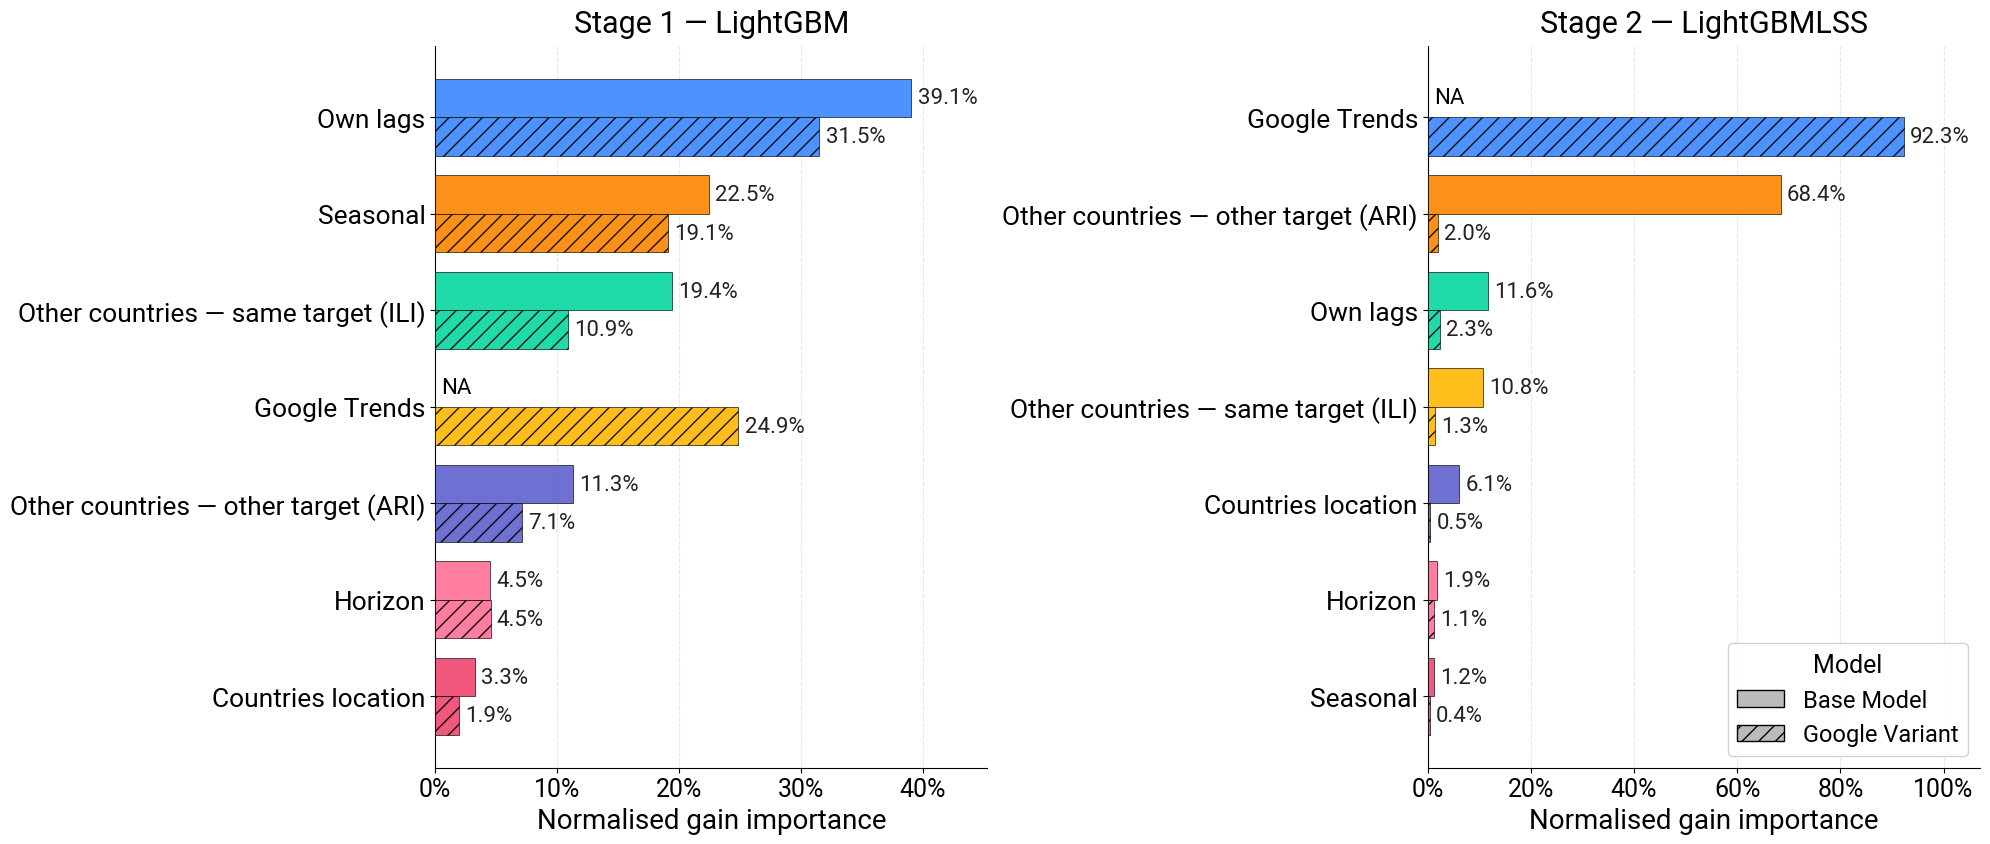

In [ ]:
fig = plot_feature_importance(
    stages=[
        ("Stage 1 — LightGBM",     grouped_s1),
        ("Stage 2 — LightGBMLSS",  grouped_s2),
    ],
    target="ILI",
    model_labels=("Base Model", "Google Variant"),   # plain / hatched
    savepath="feature_importance_grouped.png",
)

In [ ]:
 grouped_s1

{'No GT': group
 Own lags                                0.390654
 Seasonal                                0.224856
 Other countries — same target (ILI)     0.193915
 Other countries — other target (ARI)    0.112921
 Horizon                                 0.044827
 Countries location                      0.032828
 EU stats — ILI                          0.000000
 EU stats — ARI                          0.000000
 Name: gain_norm, dtype: float64,
 'GT processed': group
 Own lags                                0.315194
 Google Trends                           0.248781
 Seasonal                                0.191248
 Other countries — same target (ILI)     0.108956
 Other countries — other target (ARI)    0.071051
 Horizon                                 0.045376
 Countries location                      0.019395
 EU stats — ARI                          0.000000
 EU stats — ILI                          0.000000
 Name: gain_norm, dtype: float64}

In [ ]:
grouped_s2

{'No GT': group
 Other countries — other target (ARI)    0.684078
 Own lags                                0.116247
 Other countries — same target (ILI)     0.107737
 Countries location                      0.061119
 Horizon                                 0.018856
 Seasonal                                0.011964
 EU stats — ILI                          0.000000
 EU stats — ARI                          0.000000
 Name: gain_norm, dtype: float64,
 'GT processed': group
 Google Trends                           0.922941
 Own lags                                0.023022
 Other countries — other target (ARI)    0.020160
 Other countries — same target (ILI)     0.013438
 Horizon                                 0.011384
 Countries location                      0.005112
 Seasonal                                0.003943
 EU stats — ARI                          0.000000
 EU stats — ILI                          0.000000
 Name: gain_norm, dtype: float64}